In [41]:
import pandas as pd

In [42]:
matches = pd.read_csv("../data/raw/EPL25-26.csv")
matches.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


In [43]:
# Create date time column
matches["MatchDateTime"] = pd.to_datetime(matches["Date"] + " " + matches["Time"], dayfirst=True)
matches.head()

C:\Users\harry\AppData\Local\Temp\ipykernel_35700\1028264512.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches["MatchDateTime"] = pd.to_datetime(matches["Date"] + " " + matches["Time"], dayfirst=True)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA,MatchDateTime
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86,2025-08-15 20:00:00
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86,2025-08-16 12:30:00
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08,2025-08-16 15:00:00
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97,2025-08-16 15:00:00
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92,2025-08-16 15:00:00


In [44]:
# Check for nulls in first 24 cols as that's what we care about
missing_values_count = matches.isnull().sum()
missing_values_count[0:24]

Div         0
Date        0
Time        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
Referee     0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

In [45]:
# Average goals per game 
avg_home_goals = matches.FTHG.mean()
avg_away_goals = matches.FTAG.mean()
avg_total_goals = (matches["FTHG"] + matches["FTAG"]).mean()
print(f"Average home goals: {avg_home_goals}")
print(f"Average away goals: {avg_away_goals}")
print(f"Average goals per game: {avg_total_goals}")

Average home goals: 1.5263157894736843
Average away goals: 1.2236842105263157
Average goals per game: 2.75


In [46]:
# Home win percentage
total_matches = len(matches)
total_home_wins = len(matches.loc[matches.FTR == "H"])
home_win_percentage = (total_home_wins / total_matches) * 100 
print(f"Home win percentage: {home_win_percentage}")

# Away win percentage
total_away_wins = len(matches.loc[matches.FTR == "A"])
away_win_percentage = (total_away_wins / total_matches) * 100 
print(f"Away win percentage: {away_win_percentage}")

# Draw percentage
total_draws = len(matches.loc[matches.FTR == "D"])
draw_percentage = (total_draws / total_matches) * 100 
print(f"Draw percentage: {draw_percentage}")

Home win percentage: 42.63157894736842
Away win percentage: 30.0
Draw percentage: 27.368421052631582


In [47]:
# Calculate home and away goals by team
home_goals_scored = (
    matches.groupby("HomeTeam")[["FTHG"]]
    .sum()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "FTHG": "HomeGoalsScored"
    })
)

away_goals_scored = (
    matches.groupby("AwayTeam")[["FTAG"]]
    .sum()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "FTAG": "AwayGoalsScored"
    })
)

total_goals_scored = (
    pd.merge(home_goals_scored, away_goals_scored, on="Team")
    .assign(
        TotalGoalsScored=lambda x: x["HomeGoalsScored"] + x["AwayGoalsScored"]
    )
)

total_goals_scored.head()

,Team,HomeGoalsScored,AwayGoalsScored,TotalGoalsScored
0,Arsenal,41,30,71
1,Aston Villa,32,24,56
2,Bournemouth,29,29,58
3,Brentford,33,22,55
4,Brighton,30,22,52


In [48]:
# Calculate teams goals conceded
home_goals_conceded = (
    matches.groupby("HomeTeam")[["FTAG"]]
    .sum()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "FTAG": "HomeGoalsConceded"
    })
)

away_goals_conceded = (
    matches.groupby("AwayTeam")[["FTHG"]]
    .sum()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "FTHG": "AwayGoalsConceded"
    })
)

total_goals_conceded = (
    pd.merge(home_goals_conceded, away_goals_conceded, on="Team")
    .assign(
        TotalGoalsConceded=lambda x: x["HomeGoalsConceded"] + x["AwayGoalsConceded"]
    )
)

In [49]:
# Shots for per team, home and away
avg_home_shots_for = (
    matches.groupby("HomeTeam")[["HS"]]
    .mean()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "HS": "AvgHomeShotsFor"
    })
)

avg_away_shots_for = (
    matches.groupby("AwayTeam")[["AS"]]
    .mean()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "AS": "AvgAwayShotsFor"
    })
)

avg_home_shots_on_target_for = (
    matches.groupby("HomeTeam")[["HST"]]
    .mean()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "HST": "AvgHomeShotsOnTargetFor"
    })
)

avg_away_shots_on_target_for = (
    matches.groupby("AwayTeam")[["AST"]]
    .mean()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "AST": "AvgAwayShotsOnTargetFor"
    })
)

avg_total_shots_for = (
    pd.merge(avg_home_shots_for, avg_away_shots_for, on="Team")
    .assign(
        AvgShotsFor=lambda x: (x["AvgHomeShotsFor"] + x["AvgAwayShotsFor"]) / 2
    )
)

avg_total_shots_on_target_for = (
    pd.merge(avg_home_shots_on_target_for, avg_away_shots_on_target_for, on="Team")
    .assign(
        AvgShotsOnTargetFor=lambda x: (x["AvgHomeShotsOnTargetFor"] + x["AvgAwayShotsOnTargetFor"]) / 2
    )
)

In [50]:
# Shots against per team, home and away
avg_home_shots_against = (
    matches.groupby("HomeTeam")[["AS"]]
    .mean()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "AS": "AvgHomeShotsAgainst"
    })
)

avg_away_shots_against = (
    matches.groupby("AwayTeam")[["HS"]]
    .mean()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "HS": "AvgAwayShotsAgainst"
    })
)

avg_home_shots_on_target_against = (
    matches.groupby("HomeTeam")[["AST"]]
    .mean()
    .reset_index()
    .rename(columns={
        "HomeTeam": "Team",
        "AST": "AvgHomeShotsOnTargetAgainst"
    })
)

avg_away_shots_on_target_against = (
    matches.groupby("AwayTeam")[["HST"]]
    .mean()
    .reset_index()
    .rename(columns={
        "AwayTeam": "Team",
        "HST": "AvgAwayShotsOnTargetAgainst"
    })
)

avg_total_shots_against = (
    pd.merge(avg_home_shots_against, avg_away_shots_against, on="Team")
    .assign(
        AvgShotsAgainst=lambda x: (x["AvgHomeShotsAgainst"] + x["AvgAwayShotsAgainst"]) / 2
    )
)

avg_total_shots_on_target_against = (
    pd.merge(avg_home_shots_on_target_against, avg_away_shots_on_target_against, on="Team")
    .assign(
        AvgShotsOnTargetAgainst=lambda x: (x["AvgHomeShotsOnTargetAgainst"] + x["AvgAwayShotsOnTargetAgainst"]) / 2
    )
)

In [51]:
from functools import reduce

dfs = [
    total_goals_scored,
    total_goals_conceded,
    avg_total_shots_for,
    avg_total_shots_on_target_for,
    avg_total_shots_against,
    avg_total_shots_on_target_against
]

teams_stats = reduce(
    lambda left, right: pd.merge(left, right, on="Team"),
    dfs
)

teams_stats

,Team,HomeGoalsScored,AwayGoalsScored,TotalGoalsScored,HomeGoalsConceded,AwayGoalsConceded,TotalGoalsConceded,AvgHomeShotsFor,AvgAwayShotsFor,AvgShotsFor,AvgHomeShotsOnTargetFor,AvgAwayShotsOnTargetFor,AvgShotsOnTargetFor,AvgHomeShotsAgainst,AvgAwayShotsAgainst,AvgShotsAgainst,AvgHomeShotsOnTargetAgainst,AvgAwayShotsOnTargetAgainst,AvgShotsOnTargetAgainst
0,Arsenal,41,30,71,11,16,27,16.052632,13.000000,14.526316,5.000000,4.789474,4.894737,6.947368,9.368421,8.157895,1.894737,2.842105,2.368421
1,Aston Villa,32,24,56,22,27,49,13.736842,11.684211,12.710526,4.842105,4.105263,4.473684,11.368421,14.421053,12.894737,4.368421,4.473684,4.421053
2,Bournemouth,29,29,58,20,34,54,14.473684,13.157895,13.815789,4.526316,4.842105,4.684211,9.263158,16.000000,12.631579,3.105263,5.421053,4.263158
3,Brentford,33,22,55,21,31,52,12.000000,9.315789,10.657895,4.105263,3.631579,3.868421,12.421053,14.105263,13.263158,4.052632,4.473684,4.263158
4,Brighton,30,22,52,20,26,46,13.789474,12.263158,13.026316,4.947368,4.315789,4.631579,9.842105,13.473684,11.657895,3.684211,4.105263,3.894737
5,Burnley,18,20,38,29,46,75,10.842105,7.842105,9.342105,3.315789,2.894737,3.105263,16.315789,17.157895,16.736842,5.947368,5.421053,5.684211
6,Chelsea,26,32,58,25,27,52,15.157895,11.736842,13.447368,4.210526,4.421053,4.315789,10.157895,11.684211,10.921053,3.894737,4.315789,4.105263
7,Crystal Palace,19,22,41,23,28,51,13.315789,9.947368,11.631579,3.894737,3.526316,3.710526,10.684211,12.736842,11.710526,4.105263,4.421053,4.263158
8,Everton,26,21,47,27,23,50,12.210526,9.894737,11.052632,4.315789,3.263158,3.789474,11.368421,16.684211,14.026316,4.105263,4.421053,4.263158
9,Fulham,30,17,47,20,31,51,14.157895,11.157895,12.657895,4.000000,3.263158,3.631579,10.421053,13.157895,11.789474,3.263158,4.578947,3.921053


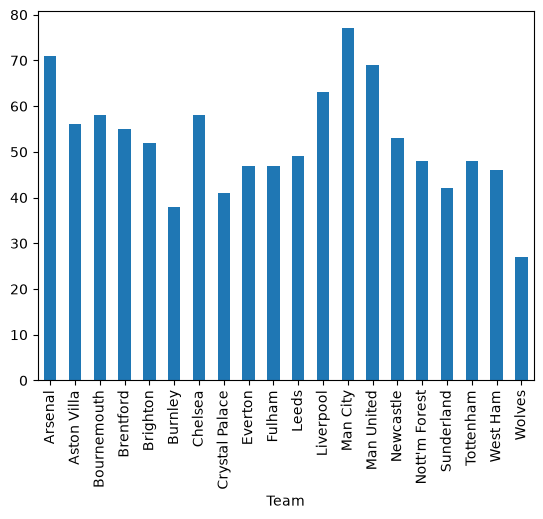

In [ ]:
# Plot of total goals scored
import matplotlib.pyplot as plt

teams_stats.plot(
    kind="bar",
    x="Team",
    y="TotalGoalsScored",
    legend=False
)
plt.show()

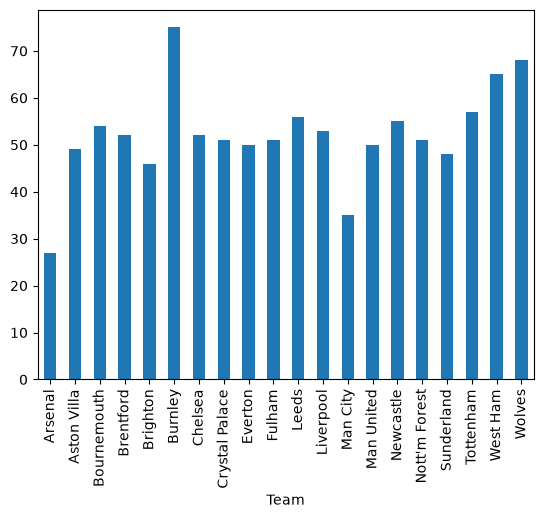

In [61]:
# Plot of total goals conceded
import matplotlib.pyplot as plt

teams_stats.plot(
    kind="bar",
    x="Team",
    y="TotalGoalsConceded",
    legend=False
)
plt.show()

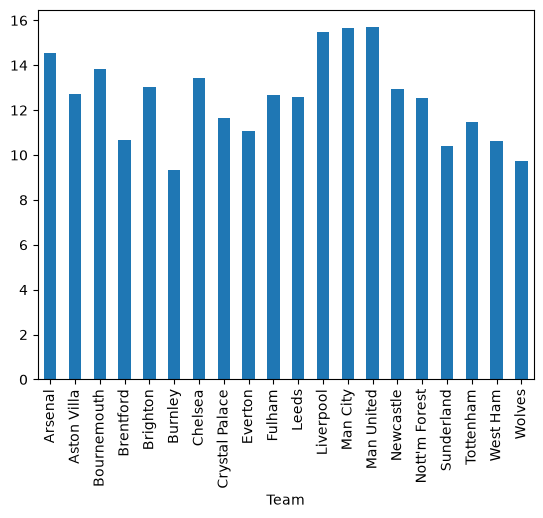

In [ ]:
# Plot of average shots for
import matplotlib.pyplot as plt

teams_stats.plot(
    kind="bar",
    x="Team",
    y="AvgShotsFor",
    legend=False
)
plt.show()

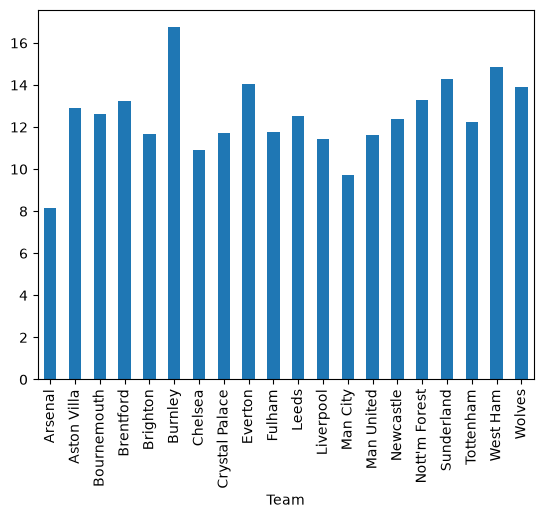

In [63]:
# Plot of average shots against
import matplotlib.pyplot as plt

teams_stats.plot(
    kind="bar",
    x="Team",
    y="AvgShotsAgainst",
    legend=False
)
plt.show()